In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from matplotlib import font_manager, rc

font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family=font_name)

In [94]:
# 2016~2019 모기지수(기온, 강수량 포함)
df = pd.read_csv("./data/mosquito_Indicator.csv", encoding="utf-8")

#2020~2025 모기지수(수변부, 거주지, 공원) 2021년부터 백분위
df_S = pd.read_csv("./data/seoul_2020_2025_mosquito.csv", encoding="euc-kr", sep=",")

# 2016~2025 강수량
df_rain = pd.read_csv("./data/rain_160501_251031.csv", encoding="euc-kr", sep=",")

# 2016~2025 기온
df_T = pd.read_csv("./data/temp_160501_251031.csv", encoding="utf-8", sep=",")

# 질병관리청 연도별 말라리아, 서울특별시[2025년 7월호]해외 모기 매개 바이러스 감염병, 질병관리청 해외유입모기 감염볌병 개
df_V = pd.read_csv("./data/mosquito_virus.csv", encoding="utf-8", sep=",")
print(df)
print(df_rain)
print(df_T)
print(df_V)

            date  mosquito_Indicator  rain(mm)  mean_T(℃)  min_T(℃)  max_T(℃)
0     2016-05-01               254.4       0.0       18.8      12.2      26.0
1     2016-05-02               273.5      16.5       21.1      16.5      28.4
2     2016-05-03               304.0      27.0       12.9       8.9      17.6
3     2016-05-04               256.2       0.0       15.7      10.2      20.6
4     2016-05-05               243.8       7.5       18.9      10.2      26.9
...          ...                 ...       ...        ...       ...       ...
1337  2019-12-27                 5.5       0.0       -1.7      -4.6       2.6
1338  2019-12-28                 5.5       0.0        1.1      -3.6       6.1
1339  2019-12-29                 5.5       1.4        3.8       1.1       6.2
1340  2019-12-30                 5.5       0.4        2.7      -5.7       6.8
1341  2019-12-31                 5.5       0.0       -7.9     -10.9      -4.5

[1342 rows x 6 columns]
     \t지점번호  지점명          일시  강수량(mm)  

## 데이터 중복값 NaN값 제거

In [9]:
# 각 파일들의 중복값 확인
print(df[df.duplicated()])
print(df.duplicated().sum())

print(df_S[df_S.duplicated()])
print(df_S.duplicated().sum())

print(df_rain[df_rain.duplicated()])
print(df_rain.duplicated().sum())

print(df_T[df_T.duplicated()])
print(df_T.duplicated().sum())


            date  mosquito_Indicator  rain(mm)  mean_T(℃)  min_T(℃)  max_T(℃)
393   2017-06-01               406.9       0.0       23.3      20.0      27.0
394   2017-06-01               406.9       0.0       23.3      20.0      27.0
395   2017-06-01               406.9       0.0       23.3      20.0      27.0
406   2017-06-11               422.0       0.0       22.8      14.8      29.6
420   2017-06-24              1000.0       3.5       24.5      21.5      27.8
423   2017-06-26              1000.0      29.0       23.1      20.1      29.9
438   2017-07-10               928.4     144.5       24.0      22.6      25.4
439   2017-07-10               928.4     144.5       24.0      22.6      25.4
440   2017-07-10               928.4     144.5       24.0      22.6      25.4
467   2017-08-05               380.0       0.0       31.4      27.6      34.8
468   2017-08-05               380.0       0.0       31.4      27.6      34.8
469   2017-08-05               380.0       0.0       31.4      2

In [10]:
# 파일 데이터 오염을 막기 위해 복제후 중복값 삭제
df1 = df
df1 = df1.drop_duplicates()
df1.reset_index(drop=True, inplace=True)
print(df1.shape)

df_S1 = df_S
df_S1 = df_S1.drop_duplicates()
df_S1.reset_index(drop=True, inplace=True)
print(df_S1.shape)


df_rain1 = df_rain
df_rain1 = df_rain1.drop_duplicates()
df_rain1.reset_index(drop=True, inplace=True)
print(df_rain1.shape)

df_T1 = df_T
df_T1 = df_T1.drop_duplicates()
df_T1.reset_index(drop=True, inplace=True)
print(df_T1.shape)


(1295, 6)
(1104, 4)
(1843, 6)
(1840, 9)


In [97]:
df1 = df1.copy()

df1["date"] = pd.to_datetime(df1["date"])
df1.info()

df1["month"] = df1["date"].dt.month
df1["year"] = df1["date"].dt.year

df_S1 = df_S1.copy()

df_S1["모기지수 발생일"] = pd.to_datetime(df_S1["모기지수 발생일"])
df_S1.info()

df_S1["month"] = df_S1["모기지수 발생일"].dt.month
df_S1["year"] = df_S1["모기지수 발생일"].dt.year

df_rain1 = df_rain1.copy()

df_rain1["일시"] = pd.to_datetime(df_rain1["일시"])
df_rain1.info()

df_rain1["month"] = df_rain1["일시"].dt.month
df_rain1["year"] = df_rain1["일시"].dt.year

df_T1 = df_T1.copy()

df_T1["일시"] = pd.to_datetime(df_T1["일시"])
df_T1.info()

df_T1["month"] = df_T1["일시"].dt.month
df_T1["year"] = df_T1["일시"].dt.year


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1295 entries, 0 to 1294
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                1295 non-null   datetime64[ns]
 1   mosquito_Indicator  1295 non-null   float64       
 2   rain(mm)            1295 non-null   float64       
 3   mean_T(℃)           1295 non-null   float64       
 4   min_T(℃)            1295 non-null   float64       
 5   max_T(℃)            1295 non-null   float64       
 6   month               1295 non-null   int32         
 7   year                1295 non-null   int32         
 8   평균온도                1295 non-null   float64       
 9   비온날                 1295 non-null   int64         
dtypes: datetime64[ns](1), float64(6), int32(2), int64(1)
memory usage: 91.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1104 entries, 0 to 1103
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dty

In [51]:
# 각 파일들의 NaN값 확인
print(df1.isnull().sum())

print(df_S1.isnull().sum())

print(df_rain1.isnull().sum())

print(df_T1.isnull().sum())

date                  0
mosquito_Indicator    0
rain(mm)              0
mean_T(℃)             0
min_T(℃)              0
max_T(℃)              0
month                 0
year                  0
dtype: int64
모기지수 발생일     0
모기지수(수변부)    0
모기지수(주거지)    0
모기지수(공원)     0
month        0
year         0
dtype: int64
\t지점번호          0
지점명             0
일시              0
강수량(mm)         0
1시간최다강수량(mm)    0
month           0
year            0
dtype: int64
지점번호       0
지점명        0
일시         0
평균기온(℃)    0
최고기온(℃)    0
최저기온(℃)    0
일교차        0
month      0
year       0
dtype: int64


In [46]:
# rain 파일의 NaN값 제거
df_rain1 = df_rain1.dropna(subset=["일시"])

df_rain1["강수량(mm)"] = df_rain1["강수량(mm)"].fillna(0)
df_rain1["1시간최다강수량(mm)"] = df_rain1["1시간최다강수량(mm)"].fillna(0)
# 필요없는 데이터인 최다 강수량시각 삭제
# df_rain1 = df_rain1.drop(columns=["1시간최다강수량시각"])

In [44]:
# 값이 다 똑같아서 이전의 값 채우기
df_rain1["\t지점번호"] = df_rain1["\t지점번호"].ffill()
df_rain1["지점명"] = df_rain1["지점명"].ffill()

In [48]:
# 필요없는 데이터인 최고기온시각, 최저기온시각 삭제
df_T1 = df_T1.drop(columns=["최고기온시각", "최저기온시각"])

In [50]:
# 기온은 비슷한 값이 예상되기에 이전값 추가
df_T1["최고기온(℃)"] = df_T1["최고기온(℃)"].ffill()
df_T1["최저기온(℃)"] = df_T1["최저기온(℃)"].ffill()

In [62]:
df1 = df1.drop(columns=["연간강수량"])

In [64]:
monthly = df1.groupby("month")["mosquito_Indicator"].mean()

In [65]:
yearly = df1.groupby("year")["mosquito_Indicator"].mean()

## 모기매개 질병과 모기지수와의 상관관계

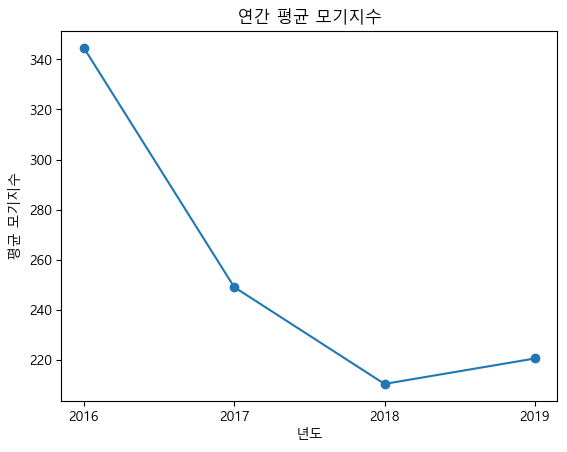

In [72]:
# 연간 평균 모기지수 그래프 표현 2016~2019
plt.figure()
plt.plot(yearly.index, yearly.values, marker="o")
plt.xlabel("년도")
plt.ylabel("평균 모기지수")
plt.title("연간 평균 모기지수")
plt.xticks(yearly.index)
plt.show()

In [119]:
# 2019년까지의 평균 모기지수 질병파일이랑 병합 준비 
df1_year = (df1[df1["year"] <= 2019].groupby("year", as_index=False)["mosquito_Indicator"].mean())
df1_year

,year,mosquito_Indicator
0,2016,344.623140
1,2017,248.985319
2,2018,210.266467
3,2019,220.433240


In [120]:
# 질병데이터 2019년깢
df_V_2019 = df_V[df_V["발생연도"] <= 2019].copy()
# 컬럼명 통일
df_V_2019 = df_V_2019.rename(columns={"발생연도":"year"})
df_V_2019

,year,말라리아,뎅기열,치쿤구니야열,지카바이러스 감염증
0,2016,673,313,10,16
1,2017,515,171,5,11
2,2018,576,159,3,3
3,2019,559,273,16,3


In [117]:
# year를 기준으로 질병데이터와 평균 모기지수 데이터 합
df_plot = pd.merge(df_V_2019, df1_year, on="year")

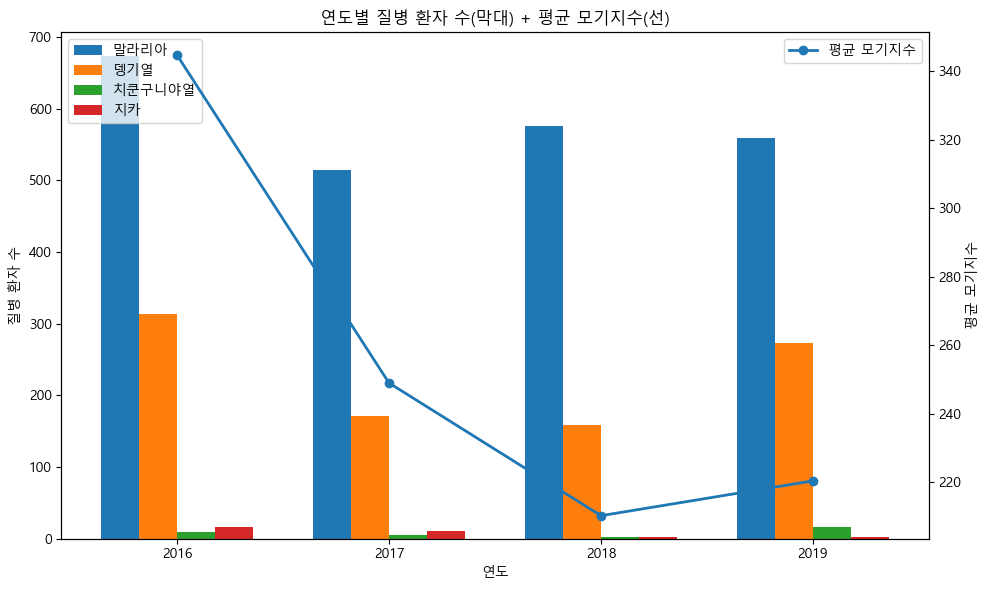

In [125]:
# 그래프로 시각화
years = df_plot["year"]
x = np.arange(len(years))
width = 0.18

fig, ax1 = plt.subplots(figsize=(10,6))

# 막대 4개
ax1.bar(x - 1.5*width, df_plot["말라리아"], width, label="말라리아")
ax1.bar(x - 0.5*width, df_plot["뎅기열"], width, label="뎅기열")
ax1.bar(x + 0.5*width, df_plot["치쿤구니야열"], width, label="치쿤구니야열")
ax1.bar(x + 1.5*width, df_plot["지카바이러스 감염증"], width, label="지카")

ax1.set_ylabel("질병 환자 수")
ax1.set_xlabel("연도")
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.legend(loc="upper left")

# 선 그래프 (모기지수)
ax2 = ax1.twinx()
ax2.plot(x, df_plot["mosquito_Indicator"], marker="o", linewidth=2, label="평균 모기지수")

ax2.set_ylabel("평균 모기지수")
ax2.legend(loc="upper right")

plt.title("연도별 질병 환자 수(막대) + 평균 모기지수(선)")
plt.tight_layout()
plt.show()

In [122]:
# 질병들의 합계와 평균 모기지수를 비교하기 위해 행들을 더함 
df_plot = df_plot.copy()

df_plot["질병총합"] = (
    df_plot["말라리아"] + df_plot["뎅기열"] + df_plot["치쿤구니야열"] + df_plot["지카바이러스 감염증"])

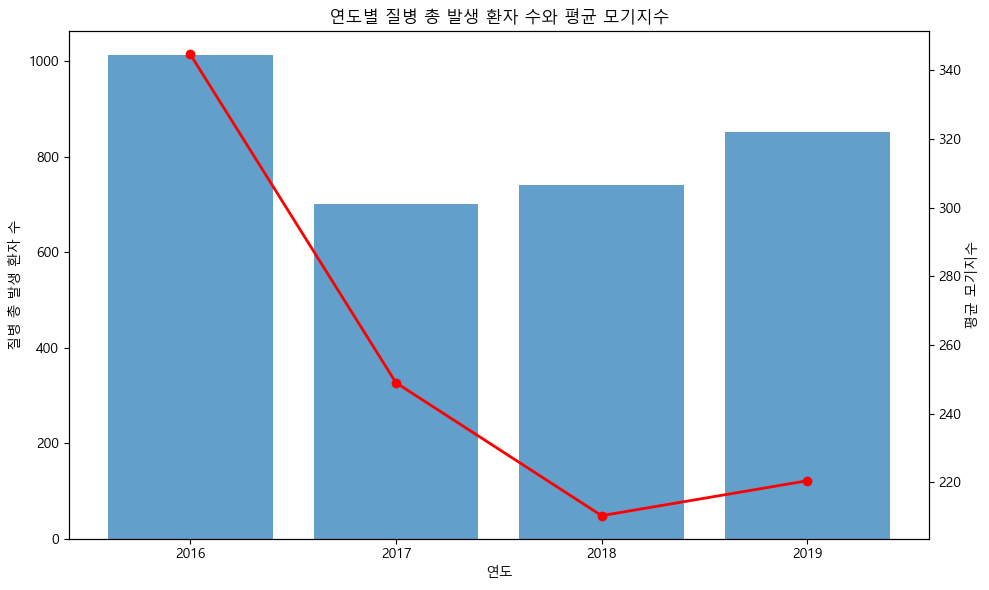

In [130]:
# 모기지수와 질병간의 상관관계를 위한 그래프
x = np.arange(len(df_plot["year"]))

fig, ax1 = plt.subplots(figsize=(10,6))

# 질병 총합 (막대)
ax1.bar(x, df_plot["질병총합"], zorder=1, alpha=0.7)
ax1.set_xlabel("연도")
ax1.set_ylabel("질병 총 발생 환자 수")
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot["year"])

# 모기지수 (선)
ax2 = ax1.twinx()
ax2.plot(x, df_plot["mosquito_Indicator"], marker="o", linewidth=2, color="red", zorder=3)
ax2.set_ylabel("평균 모기지수")

plt.title("연도별 질병 총 발생 환자 수와 평균 모기지수")
plt.tight_layout()
plt.show()

## 강수량 기온과 모기지수와의 상관관계 그래프 시각화

In [131]:
df_mosq_month = (df1.groupby(["year", "month"], as_index=False)["mosquito_Indicator"].mean())

In [149]:
mosq_month = (
    df1.groupby(["year", "month"])["mosquito_Indicator"]
    .mean()
)

rain_month = (
    df1.groupby(["year", "month"])["rain(mm)"]
    .sum()
)

temp_month = (
    df1.groupby(["year", "month"])["mean_T(℃)"]
    .mean()
)

# 2016–2019 평균 월 패턴
mosq_season = mosq_month.groupby("month").mean()
rain_season = rain_month.groupby("month").mean()
temp_season = temp_month.groupby("month").mean()


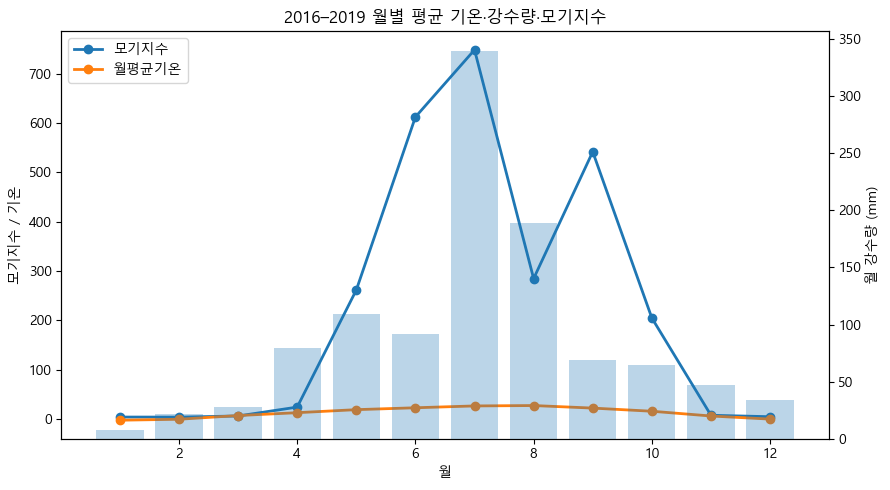

In [150]:
fig, ax1 = plt.subplots(figsize=(9,5))

# 모기지수 & 기온 (선)
ax1.plot(mosq_season.index, mosq_season.values,
         marker="o", linewidth=2, label="모기지수")
ax1.plot(temp_season.index, temp_season.values,
         marker="o", linewidth=2, label="월평균기온")

ax1.set_xlabel("월")
ax1.set_ylabel("모기지수 / 기온")
ax1.legend(loc="upper left")

# 강수량 (막대, 보조축)
ax2 = ax1.twinx()
ax2.bar(rain_season.index, rain_season.values,
        alpha=0.3, label="월 강수량")
ax2.set_ylabel("월 강수량 (mm)")

plt.title("2016–2019 월별 평균 기온·강수량·모기지수")
plt.tight_layout()
plt.show()


In [154]:
mosq_year = (df1.groupby("year", as_index=False)["mosquito_Indicator"].mean())

temp_year = (df1.groupby("year", as_index=False)["mean_T(℃)"].mean())

rain_year = (df1.groupby("year", as_index=False)["rain(mm)"].sum())


In [155]:
df_year_plot = (mosq_year.merge(temp_year, on="year").merge(rain_year, on="year"))

df_year_plot

,year,mosquito_Indicator,mean_T(℃),rain(mm)
0,2016,344.623140,18.136777,825.8
1,2017,248.985319,13.067590,1208.7
2,2018,210.266467,13.200000,1263.6
3,2019,220.433240,13.389106,891.1


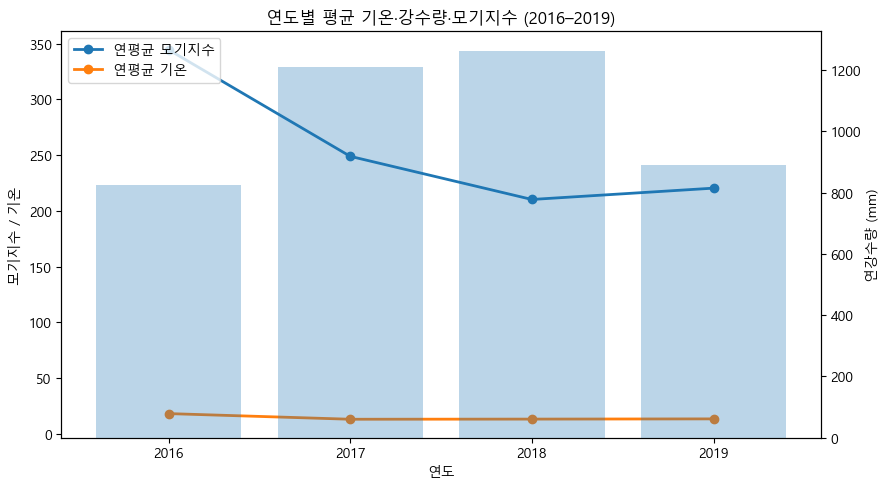

In [161]:
# 평균으로 시각화한거라 애매함
x = np.arange(len(df_year_plot["year"]))

fig, ax1 = plt.subplots(figsize=(9,5))

# 모기지수 & 기온 (선)
ax1.plot(
    x,
    df_year_plot["mosquito_Indicator"],
    marker="o",
    linewidth=2,
    label="연평균 모기지수",
    zorder=3
)
ax1.plot(
    x,
    df_year_plot["mean_T(℃)"],
    marker="o",
    linewidth=2,
    label="연평균 기온",
    zorder=3
)

ax1.set_xlabel("연도")
ax1.set_ylabel("모기지수 / 기온")
ax1.set_xticks(x)
ax1.set_xticklabels(df_year_plot["year"])
ax1.legend(loc="upper left")

# 강수량 (막대)
ax2 = ax1.twinx()
ax2.bar(
    x,
    df_year_plot["rain(mm)"],
    alpha=0.3,
    label="연강수량",
    zorder=1
)
ax2.set_ylabel("연강수량 (mm)")

plt.title("연도별 평균 기온·강수량·모기지수 (2016–2019)")
plt.tight_layout()
plt.show()


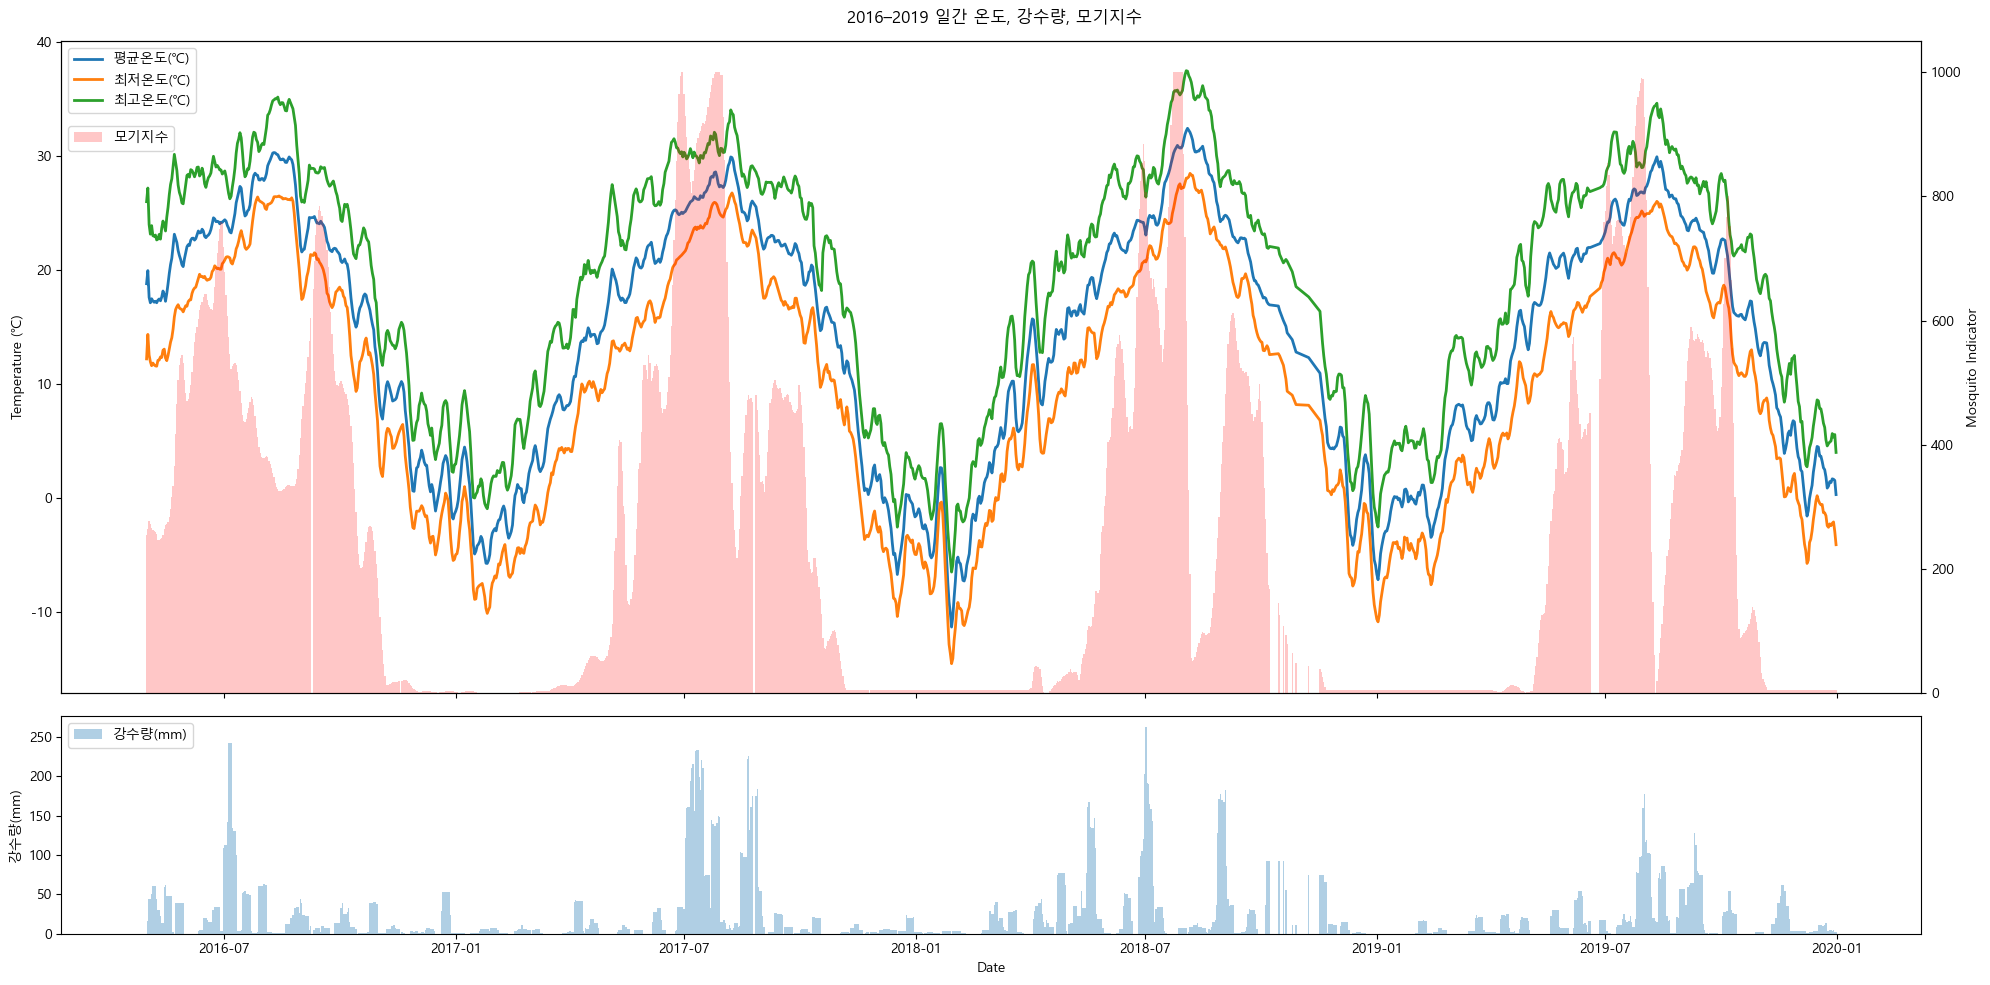

In [168]:
# 1) 2016~2019 필터 + 정렬, 아직 해석 덜됨
dfp = df1.copy()
dfp["date"] = pd.to_datetime(dfp["date"])

# 2) 7일 이동평균/합계로 노이즈 완화
# - 기온/모기지수: 이동평균
# - 강수량: 이동합계(비는 누적이 의미있어서)
use_smooth = True
if use_smooth:
    dfp["mean_T(℃)"] = dfp["mean_T(℃)"].rolling(7, min_periods=1).mean()
    dfp["min_T(℃)"]  = dfp["min_T(℃)"].rolling(7, min_periods=1).mean()
    dfp["max_T(℃)"]  = dfp["max_T(℃)"].rolling(7, min_periods=1).mean()
    dfp["mosquito_Indicator"] = dfp["mosquito_Indicator"].rolling(7, min_periods=1).mean()
    dfp["rain(mm)"] = dfp["rain(mm)"].rolling(7, min_periods=1).sum()

# 3) 2단 구성(위: 기온+모기 / 아래: 강수)
fig, (ax1, ax_rain) = plt.subplots(
    2, 1, figsize=(20, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- 위(기온 3개) ---
ax1.plot(dfp["date"], dfp["mean_T(℃)"], label="평균온도(℃)", linewidth=2, zorder=3)
ax1.plot(dfp["date"], dfp["min_T(℃)"],  label="최저온도(℃)",  linewidth=2, zorder=3)
ax1.plot(dfp["date"], dfp["max_T(℃)"],  label="최고온도(℃)",  linewidth=2, zorder=3)
ax1.set_ylabel("Temperature (℃)")
ax1.legend(loc="upper left")

# --- 위(모기지수: 오른쪽 축, 막대) ---
ax2 = ax1.twinx()
ax2.bar(
    dfp["date"], dfp["mosquito_Indicator"],
    width=1.0, alpha=0.22, label="모기지수", zorder=1, color="red"
)
ax2.set_ylabel("Mosquito Indicator")
ax2.legend(loc="upper left", bbox_to_anchor=(0.0, 0.88))

# --- 아래(강수량 막대) ---
ax_rain.bar(
    dfp["date"], dfp["rain(mm)"],
    width=1.0, alpha=0.35, label="강수량(mm)"
)
ax_rain.set_ylabel("강수량(mm)")
ax_rain.set_xlabel("Date")
ax_rain.legend(loc="upper left")

plt.suptitle("2016–2019 일간 온도, 강수량, 모기지수", y=0.98)
plt.tight_layout()
plt.show()
